In [1]:
import os
os.environ["TQDM_DISABLE"] = "1"

import numpy as np
import pandas as pd
import time
import zlib

from typing import Callable, Optional, Dict, Any, Tuple
from types import SimpleNamespace
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier

from pfn_cf_guided_onehot import *
from make_mock_cont import *
from get_real_datasets import *
from preprocessing import *

from __future__ import annotations
from dataclasses import dataclass

from tabpfn import TabPFNClassifier
from xgboost import XGBClassifier

from nice import NICE
import logging
import dice_ml
from dice_ml import Model
from dice_ml import Dice
logging.getLogger("dice_ml").setLevel(logging.WARNING)

#import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
try:
    from dice_ml.utils.exception import UserConfigValidationException
except ImportError:
    UserConfigValidationException = Exception  # fallback

In [3]:
def build_nice_explainer(
    *,
    X_train_sc: np.ndarray,
    y_train: np.ndarray,
    predict_fn_proba: Callable[[np.ndarray], np.ndarray],
    feature_info: Optional[FeatureInfo] = None,
    nice_opt: str = 'none',
    # Raw-space arguments for proper categorical handling
    X_tr_raw_df=None,   # raw training features WITHOUT outcome column
    model=None,          # fitted classifier
    pre=None,            # fitted ColumnTransformer
    num_cols=None,       # list of numeric column names
    cat_cols=None,       # list of categorical column names
):
    """
    Build NICE object once. Reuse it across factual points.

    When X_tr_raw_df + model + pre + num_cols + cat_cols are supplied AND cat_cols is
    non-empty, NICE operates in the original (pre-OHE) feature space with ordinal-encoded
    categoricals.  This is the correct usage of NICE and avoids the distortion caused by
    treating individual one-hot dummy columns as independent categorical features.

    Otherwise falls back to OHE-space behaviour (used for num-only / synthetic datasets).
    """
    from nice import NICE
    from sklearn.preprocessing import OrdinalEncoder

    use_raw_space = (
        X_tr_raw_df is not None
        and cat_cols is not None
        and len(cat_cols) > 0
        and model is not None
        and pre is not None
    )

    if use_raw_space:
        all_cols = list(num_cols) + list(cat_cols)
        X_raw = X_tr_raw_df[all_cols].copy()

        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1,
                            dtype=np.float64)
        X_raw[cat_cols] = oe.fit_transform(X_raw[cat_cols])
        X_nice = X_raw[all_cols].to_numpy(dtype=np.float64)

        n_num = len(num_cols)
        num_feat = list(range(n_num))
        cat_feat = list(range(n_num, len(all_cols)))

        # Capture in closure to avoid late-binding issues
        _pre, _model, _oe = pre, model, oe
        _num_cols, _cat_cols, _all_cols = list(num_cols), list(cat_cols), all_cols

        def _predict_fn(X_arr):
            df = pd.DataFrame(X_arr.astype(object), columns=_all_cols)
            df[_cat_cols] = _oe.inverse_transform(
                np.asarray(X_arr[:, n_num:], dtype=np.float64)
            )
            for c in _num_cols:
                df[c] = pd.to_numeric(df[c], errors='coerce')
            Xsc = _pre.transform(df)
            if hasattr(Xsc, 'toarray'):
                Xsc = Xsc.toarray()
            return _model.predict_proba(np.asarray(Xsc, dtype=np.float64))

        nice_obj = NICE(
            X_train=X_nice,
            predict_fn=_predict_fn,
            y_train=y_train,
            cat_feat=cat_feat,
            num_feat=num_feat,
            distance_metric='HEOM',
            num_normalization='minmax',
            optimization=nice_opt,
            justified_cf=True,
        )
        nice_ctx = SimpleNamespace(
            use_raw_space=True,
            oe=oe,
            all_cols=all_cols,
            num_cols=list(num_cols),
            cat_cols=list(cat_cols),
            pre=pre,
        )
        return nice_obj, nice_ctx

    # ---- fallback: OHE-space (num-only or synthetic datasets) ----
    d = X_train_sc.shape[1]

    if feature_info is not None and len(getattr(feature_info, "cat_groups", [])) > 0:
        cat_cols_sc = np.concatenate([np.asarray(g, int) for g in feature_info.cat_groups]).tolist()
        if feature_info.num_idx is not None:
            num_feat = np.asarray(feature_info.num_idx, int).tolist()
        else:
            mask = np.ones(d, dtype=bool)
            mask[np.asarray(cat_cols_sc, int)] = False
            num_feat = np.flatnonzero(mask).tolist()
        cat_feat = cat_cols_sc
    else:
        cat_feat = []
        num_feat = list(range(d))

    nice_obj = NICE(
        X_train=X_train_sc,
        predict_fn=predict_fn_proba,
        y_train=y_train,
        cat_feat=cat_feat,
        num_feat=num_feat,
        distance_metric="HEOM",
        num_normalization="minmax",
        optimization=nice_opt,
        justified_cf=True,
    )
    nice_ctx = SimpleNamespace(use_raw_space=False)
    return nice_obj, nice_ctx


def _sc_to_nice_vec(x_sc: np.ndarray, nice_ctx) -> np.ndarray:
    """Convert a model-space (scaled/OHE) vector to NICE's ordinal raw space."""
    raw = inverse_preprocess(x_sc, nice_ctx.pre)
    row = []
    for c in nice_ctx.all_cols:
        if c in nice_ctx.num_cols:
            row.append(float(raw.get(c, np.nan)))
        else:
            row.append(raw.get(c, None))
    df = pd.DataFrame([row], columns=nice_ctx.all_cols)
    df[nice_ctx.cat_cols] = nice_ctx.oe.transform(df[nice_ctx.cat_cols])
    for c in nice_ctx.num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    return df[nice_ctx.all_cols].to_numpy(dtype=np.float64).ravel()


def _nice_vec_to_sc(x_nice: np.ndarray, nice_ctx) -> np.ndarray:
    """Convert a NICE ordinal-space vector back to model space (scaled/OHE)."""
    n_num = len(nice_ctx.num_cols)
    df = pd.DataFrame([x_nice], columns=nice_ctx.all_cols, dtype=object)
    df[nice_ctx.cat_cols] = nice_ctx.oe.inverse_transform(
        np.asarray([x_nice[n_num:]], dtype=np.float64)
    )
    for c in nice_ctx.num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    Xsc = nice_ctx.pre.transform(df)
    if hasattr(Xsc, 'toarray'):
        Xsc = Xsc.toarray()
    return np.asarray(Xsc, dtype=np.float64).ravel()


@dataclass
class CFOut:
    x_cf: Optional[np.ndarray]
    rep: Dict[str, Any]
    meta: Dict[str, Any]


def _extract_cf_from_nice_result(res) -> Optional[np.ndarray]:
    """Tries hard to extract a CF vector from whatever NICE returns."""
    if res is None:
        return None
    if isinstance(res, np.ndarray):
        if res.ndim == 2 and res.shape[0] == 1:
            return res[0]
        if res.ndim == 1:
            return res
    return None


def nice_cf_one(
    *,
    nice_obj,
    x_f_sc: np.ndarray,
    predict_proba_target: PredictProbaFn,
    proba_threshold: float = 0.5,
    tol: float = 1e-6,
    feature_info: Optional["FeatureInfo"] = None,
    repair_onehot: bool = False,
    nice_ctx=None,   # SimpleNamespace from build_nice_explainer
) -> CFOut:
    """
    Run NICE for one factual and return a standardized output.

    If nice_ctx.use_raw_space is True, the factual is converted to ordinal space before
    calling NICE and the CF is converted back to model space for metric computation.
    This is the correct workflow for datasets with categorical features.
    """
    t0 = time.perf_counter()

    x_f_sc = np.asarray(x_f_sc, dtype=np.float32).reshape(-1)
    p_f = float(predict_proba_target(x_f_sc[None, :])[0])
    yhat_f = int(p_f >= proba_threshold)
    y_desired = 1 - yhat_f

    # ---- raw-space path (proper categorical handling) ----
    if nice_ctx is not None and nice_ctx.use_raw_space:
        try:
            x_f_nice = _sc_to_nice_vec(x_f_sc, nice_ctx)
            res = nice_obj.explain(x_f_nice[None, :])
        except Exception as e:
            return CFOut(
                x_cf=None,
                rep={"status": "exception", "exception": repr(e)},
                meta={"method": "NICE"},
            )

        x_cf_nice = _extract_cf_from_nice_result(res)
        if x_cf_nice is None:
            return CFOut(
                x_cf=None,
                rep={"status": "no_cf"},
                meta={"method": "NICE", "raw": res},
            )

        try:
            x_cf = _nice_vec_to_sc(x_cf_nice, nice_ctx)
        except Exception as e:
            return CFOut(
                x_cf=None,
                rep={"status": "decode_error", "exception": repr(e)},
                meta={"method": "NICE"},
            )

        x_f_sc_f64 = x_f_sc.astype(np.float64)
        p_cf = float(predict_proba_target(x_cf[None, :])[0])
        yhat_cf = int(p_cf >= proba_threshold)
        dt = time.perf_counter() - t0

        if yhat_cf != y_desired:
            return CFOut(
                x_cf=x_cf,
                rep={
                    "status": "not_flipped",
                    "p_f": float(p_f), "p_cf": float(p_cf),
                    "yhat_f": int(yhat_f), "y_desired": int(y_desired),
                    "yhat_cf": int(yhat_cf), "time_s": float(dt),
                },
                meta={"method": "NICE", "raw": res},
            )

        diff = x_cf - x_f_sc_f64
        if feature_info is not None and len(getattr(feature_info, "cat_groups", [])) > 0:
            cat_groups = [np.asarray(g, int) for g in feature_info.cat_groups]
            if getattr(feature_info, "num_idx", None) is not None:
                num_idx = np.asarray(feature_info.num_idx, int)
            else:
                all_cat = np.concatenate(cat_groups)
                num_idx = np.flatnonzero(~np.isin(np.arange(len(x_f_sc)), all_cat))
            l0 = int(l0_group_aware(x_f_sc_f64, x_cf[None, :],
                                     num_idx=num_idx, cat_groups=cat_groups, tol=tol)[0])
        else:
            l0 = int(np.sum(np.abs(diff) > tol))
        l2 = float(np.sqrt(np.sum(diff * diff)))

        return CFOut(
            x_cf=x_cf,
            rep={
                "status": "ok",
                "p_f": float(p_f), "p_cf": float(p_cf),
                "yhat_f": int(yhat_f), "y_desired": int(y_desired),
                "l0": int(l0), "l2": float(l2), "time_s": float(dt),
            },
            meta={"method": "NICE", "raw": res, "raw_space": True},
        )

    # ---- OHE-space path (fallback for num-only / synthetic datasets) ----
    try:
        res = nice_obj.explain(x_f_sc[None, :])
    except Exception as e:
        return CFOut(
            x_cf=None,
            rep={"status": "exception", "exception": repr(e)},
            meta={"method": "NICE"},
        )

    x_cf = _extract_cf_from_nice_result(res)
    if x_cf is None:
        return CFOut(
            x_cf=None,
            rep={"status": "no_cf"},
            meta={"method": "NICE", "raw": res},
        )

    x_cf = np.asarray(x_cf, dtype=np.float32).reshape(-1)

    if feature_info is not None and len(getattr(feature_info, "cat_groups", [])) > 0:
        cat_groups = [np.asarray(g, dtype=int) for g in feature_info.cat_groups]

        if repair_onehot:
            x_cf = x_cf.copy()
            for g in cat_groups:
                j = int(g[np.argmax(x_cf[g])])
                x_cf[g] = 0.0
                x_cf[j] = 1.0
        else:
            if not onehot_valid_mask(x_cf[None, :], cat_groups, tol=tol)[0]:
                dt = time.perf_counter() - t0
                return CFOut(
                    x_cf=x_cf,
                    rep={"status": "invalid_onehot", "time_s": float(dt)},
                    meta={"method": "NICE", "raw": res},
                )

        immutable_num = getattr(feature_info, "immutable_num", frozenset())
        if immutable_num:
            for j in immutable_num:
                if abs(float(x_cf[int(j)] - x_f_sc[int(j)])) > tol:
                    dt = time.perf_counter() - t0
                    return CFOut(
                        x_cf=x_cf,
                        rep={"status": "violates_immutable", "feature": int(j), "time_s": float(dt)},
                        meta={"method": "NICE", "raw": res},
                    )

    p_cf = float(predict_proba_target(x_cf[None, :])[0])
    yhat_cf = int(p_cf >= proba_threshold)

    if yhat_cf != y_desired:
        dt = time.perf_counter() - t0
        return CFOut(
            x_cf=x_cf,
            rep={
                "status": "not_flipped",
                "p_f": float(p_f), "p_cf": float(p_cf),
                "yhat_f": int(yhat_f), "y_desired": int(y_desired),
                "yhat_cf": int(yhat_cf), "time_s": float(dt),
            },
            meta={"method": "NICE", "raw": res},
        )

    diff = x_cf - x_f_sc

    if feature_info is not None and len(getattr(feature_info, "cat_groups", [])) > 0:
        d = x_f_sc.shape[0]
        cat_groups = [np.asarray(g, int) for g in feature_info.cat_groups]
        if getattr(feature_info, "num_idx", None) is not None:
            num_idx = np.asarray(feature_info.num_idx, int)
        else:
            cat_cols_mask = np.zeros(d, dtype=bool)
            for g in cat_groups:
                cat_cols_mask[g] = True
            num_idx = np.flatnonzero(~cat_cols_mask)
        l0 = int(l0_group_aware(x_f_sc, x_cf[None, :], num_idx=num_idx,
                                  cat_groups=cat_groups, tol=tol)[0])
    else:
        l0 = int(np.sum(np.abs(diff) > tol))

    l2 = float(np.sqrt(np.sum(diff * diff)))
    dt = time.perf_counter() - t0

    rep = {
        "status": "ok",
        "p_f": float(p_f), "p_cf": float(p_cf),
        "yhat_f": int(yhat_f), "y_desired": int(y_desired),
        "l0": int(l0), "l2": float(l2), "time_s": float(dt),
    }
    meta = {"method": "NICE", "raw": res, "repaired_onehot": bool(repair_onehot)}
    return CFOut(x_cf=x_cf, rep=rep, meta=meta)


In [4]:
# -------------------------
# Model wrappers (predict_proba for class 1)
# -------------------------
def fit_models(X_tr_sc, y_tr, seed=0, include_tabpfn=True):
    models = {}

    # LR
    lr = LogisticRegression(max_iter=5000, solver="lbfgs", random_state=seed)
    lr.fit(X_tr_sc, y_tr)
    models["LR"] = lr

    # RF (no scaling needed but keep inputs scaled anyway for comparability)
    rf = RandomForestClassifier(
        n_estimators=400, random_state=seed, n_jobs=-1, min_samples_leaf=2
    )
    rf.fit(X_tr_sc, y_tr)
    models["RF"] = rf

    # XGB
    xgb = XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        min_child_weight=1.0,
        gamma=0.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=seed,
        n_jobs=-1,
    )
    xgb.fit(X_tr_sc, y_tr)
    models["XGB"] = xgb

    # TABPFN
    if include_tabpfn:
        tp = TabPFNClassifier(device="auto")
        tp.fit(X_tr_sc, y_tr)
        models["TabPFN"] = tp

    return models


def proba_fn(model):
    return lambda X: model.predict_proba(X)[:, 1]


In [5]:
from sklearn.base import clone

def fit_models_for_dice(X_tr_raw_df, y_tr, pre, *, outcome_name="outcome", seed=0, models_sc=None):
    """
    Fit pipeline models for DiCE (pre -> estimator) on RAW training data.
    Uses clone(models_sc[name]) to preserve hyperparameters.
    """
    X_tr_raw = X_tr_raw_df.drop(columns=[outcome_name], errors="ignore")

    dice_models = {}

    for name in ["LR", "RF", "XGB"]:
        if models_sc is None or name not in models_sc:
            raise ValueError("Pass models_sc with fitted models to clone hyperparams cleanly.")
        est = clone(models_sc[name])   # keeps hyperparams, resets fitted state
        pipe = Pipeline([("pre", pre), ("model", est)])
        pipe.fit(X_tr_raw, y_tr)
        dice_models[name] = pipe

    return dice_models

In [6]:
@dataclass
class GuidedCFCache:
    X_tr_sc: np.ndarray
    predict_proba_guidance: PredictProbaFn

    feature_info: FeatureInfo | None

    # Cached outputs
    p_train: np.ndarray          # shape (n_train,)
    A: Any                       # stageA_build output

    anchors_by_class: Dict[int, np.ndarray]
    anchors_diag_by_class: Dict[int, Dict[str, Any]]

def guided_cf_build_cache(
    *,
    X_tr_sc: np.ndarray,
    predict_proba_target: PredictProbaFn,
    predict_proba_guidance: PredictProbaFn | None = None,
    stageA_random_state: int = 0,
    anchor_k: int = 200,
    anchors_random_state: int = 1,
    feature_info: FeatureInfo | None = None,
) -> GuidedCFCache:
    if predict_proba_guidance is None:
        predict_proba_guidance = predict_proba_target

    p_train = predict_proba_guidance(X_tr_sc).astype(np.float64)

    A = stageA_build(
        X_train=X_tr_sc,
        predict_proba_fn=predict_proba_guidance,
        random_state=stageA_random_state,
        feature_info=feature_info,
    )

    anchors_by_class = {}
    anchors_diag_by_class = {}

    for y_desired in (0, 1):
        anchors, diag = stageA_target_anchors_from_p(
            p_train=p_train,
            y_desired=y_desired,
            anchor_k=anchor_k,
            random_state=anchors_random_state,
        )
        anchors_by_class[y_desired] = anchors
        anchors_diag_by_class[y_desired] = diag

    return GuidedCFCache(
        X_tr_sc=X_tr_sc,
        predict_proba_guidance=predict_proba_guidance,
        feature_info=feature_info,
        p_train=p_train,
        A=A,
        anchors_by_class=anchors_by_class,
        anchors_diag_by_class=anchors_diag_by_class,
    )

def guided_cf_one_repeated(
    *,
    x_f_sc: np.ndarray,
    cache: GuidedCFCache,
    predict_proba_target: PredictProbaFn,
    n_candidates: int = 300,
    max_changed_features: int = 3,
    random_state=0,           
    feature_info= FeatureInfo | None, 
):
    # target-side decision (must stay per factual)
    p_f = float(predict_proba_target(x_f_sc[None, :])[0])
    yhat_f = int(p_f >= 0.5)
    y_desired = 1 - yhat_f

    anchors = cache.anchors_by_class[y_desired]
    if anchors.size == 0:
        return x_f_sc.copy(), {"ok": False}, {
            "error": "no_anchors",
            "y_desired": y_desired,
            "p_f": p_f,
        }

    C_sc, meta = stageB_generate(
        x_f=x_f_sc,
        X_train=cache.X_tr_sc,
        predict_proba_fn=cache.predict_proba_guidance,
        boundary_idx=cache.A.boundary_idx,
        anchors_idx=anchors,
        feature_weights=cache.A.feature_weights,
        unit_weights=getattr(cache.A, "unit_weights", None), 
        feature_info=cache.feature_info,             
        n_candidates=n_candidates,
        max_changed_features=max_changed_features,
        random_state=random_state,
    )

    x_cf_sc, rep = stageC_select_best(
        x_f=x_f_sc,
        C=C_sc,
        sources=meta["sources"],
        predict_proba_fn=predict_proba_target,
        y_desired=y_desired,
        feature_info=cache.feature_info,
    )

    meta = dict(meta)
    meta["anchors_diag"] = cache.anchors_diag_by_class[y_desired]
    meta["p_f"] = p_f
    meta["y_desired"] = y_desired

    return x_cf_sc, rep, meta, C_sc

In [7]:
def stable_int_seed(*parts) -> int:
    s = "|".join(map(str, parts)).encode("utf-8")
    return zlib.crc32(s) & 0xFFFFFFFF  # 0..2^32-1

In [8]:
def l0_mixed(x_f, x_cf, feature_info, tol=1e-6):
    if feature_info is None or len(getattr(feature_info, "cat_groups", [])) == 0:
        return int(np.sum(np.abs(x_cf - x_f) > tol))

    d = x_f.shape[0]
    cat_groups = [np.asarray(g, int) for g in feature_info.cat_groups]

    if getattr(feature_info, "num_idx", None) is not None:
        num_idx = np.asarray(feature_info.num_idx, int)
    else:
        cat_cols = np.zeros(d, dtype=bool)
        for g in cat_groups:
            cat_cols[g] = True
        num_idx = np.flatnonzero(~cat_cols)

    num_changed = int(np.sum(np.abs(x_cf[num_idx] - x_f[num_idx]) > tol))

    cat_changed = 0
    for g in cat_groups:
        if np.any(np.abs(x_cf[g] - x_f[g]) > tol):
            cat_changed += 1

    return num_changed + cat_changed

In [9]:
def prepare_dataset(
    ds_in,
    *,
    rng=0,
    test_size=0.25,
    ohe_sparse=True,
    make_dense=True,
    outcome_name="outcome",          # <-- standardized target column name
    dice_clip_quantiles=None,        # e.g. (0.01, 0.99)
    dice_use_immutables=True,
):

    def dice_permitted_range_from_train(X_tr_raw_df, continuous_features, clip_quantiles=None):
        pr = {}
        for c in continuous_features:
            s = pd.to_numeric(X_tr_raw_df[c], errors="coerce")
            if clip_quantiles is None:
                lo = float(np.nanmin(s.values))
                hi = float(np.nanmax(s.values))
            else:
                qlo, qhi = clip_quantiles
                lo = float(np.nanquantile(s.values, qlo))
                hi = float(np.nanquantile(s.values, qhi))
            if np.isfinite(lo) and np.isfinite(hi) and lo <= hi:
                pr[c] = [lo, hi]
        return pr

    # def dice_features_to_vary(num_cols, cat_cols):
    #     # keep this explicit; you can swap in your actionability logic later
    #     if dice_use_immutables:
    #         imm_num = {"age", "fnlwgt"} & set(num_cols)
    #         imm_cat = {"sex", "race"} & set(cat_cols)
    #         imm = imm_num | imm_cat
    #         return [c for c in list(num_cols) + list(cat_cols) if c not in imm]
    #     return list(num_cols) + list(cat_cols)

    def dice_features_to_vary(num_cols, cat_cols, immutables=None, *, dice_use_immutables=True):
        """
        Return a list of feature names DiCE is allowed to vary.
        - num_cols, cat_cols: raw feature names (pre-OHE)
        - immutables: ImmutableSpec (names), or None
        """
        cols = list(num_cols) + list(cat_cols)

        if (not dice_use_immutables) or (immutables is None):
            return cols

        imm_num = set(immutables.num) & set(num_cols)
        imm_cat = set(immutables.cat) & set(cat_cols)
        imm = imm_num | imm_cat

        return [c for c in cols if c not in imm]


    # ---------------------------
    # REAL DATASET
    # ---------------------------
    if hasattr(ds_in, "X_df"):
        X_df = ds_in.X_df
        y = np.asarray(ds_in.y).astype(int, copy=False)
        num_cols, cat_cols = list(ds_in.num_cols), list(ds_in.cat_cols)

        idx = np.arange(len(X_df))
        idx_tr, idx_te = train_test_split(
            idx, test_size=test_size, stratify=y, random_state=rng
        )

        X_tr_raw_df = X_df.iloc[idx_tr].copy()
        X_te_raw_df = X_df.iloc[idx_te].copy()
        y_tr = y[idx_tr]
        y_te = y[idx_te]

        # Add standardized outcome column for DiCE
        X_tr_raw_df[outcome_name] = y_tr
        X_te_raw_df[outcome_name] = y_te

        # Fit preprocessing on train only (features only)
        pre = make_preprocessor(num_cols, cat_cols, ohe_sparse=ohe_sparse)
        pre.fit(X_tr_raw_df.drop(columns=[outcome_name]))

        X_tr_sc = pre.transform(X_tr_raw_df.drop(columns=[outcome_name]))
        X_te_sc = pre.transform(X_te_raw_df.drop(columns=[outcome_name]))

        if make_dense and hasattr(X_tr_sc, "toarray"):
            X_tr_sc = X_tr_sc.toarray()
            X_te_sc = X_te_sc.toarray()

        X_tr_sc = np.asarray(X_tr_sc, dtype=np.float64)
        X_te_sc = np.asarray(X_te_sc, dtype=np.float64)

        immutables = getattr(ds_in, "immutables", ImmutableSpec.empty())
        has_immutables = bool(immutables.num) or bool(immutables.cat)

        if len(cat_cols) == 0 and not has_immutables:
            feature_info = None
        else:
            num_idx, cat_groups = build_feature_info_from_pre(pre, num_cols, cat_cols)
            immutable_num = safe_immutable_num(num_cols, num_idx, ds_in.immutables.num)
            immutable_cat = safe_immutable_cat(cat_cols, ds_in.immutables.cat)
            feature_info = FeatureInfo(
                num_idx=num_idx,
                cat_groups=cat_groups,
                #immutables=immutables,
                immutable_num=immutable_num,
                immutable_cat=immutable_cat,
            )

        # DiCE spec (raw space)
        continuous_features = list(num_cols)
        categorical_features = list(cat_cols)
        #immutables = getattr(ds_in, "immutables", ImmutableSpec.empty())
        dice_spec = {
            "continuous_features": continuous_features,
            "categorical_features": categorical_features,
            "outcome_name": outcome_name,
            #"features_to_vary": dice_features_to_vary(num_cols, cat_cols),
            "permitted_range": dice_permitted_range_from_train(
                X_tr_raw_df, continuous_features, clip_quantiles=dice_clip_quantiles
            ),
        }

        immutables = getattr(ds_in, "immutables", ImmutableSpec.empty())

        dice_spec["features_to_vary"] = dice_features_to_vary(
            num_cols=num_cols,
            cat_cols=cat_cols,
            immutables=immutables,
            dice_use_immutables=True,
        )

        meta = dict(getattr(ds_in, "meta", {}) or {})
        meta.update({
            "n_rows": int(len(X_df)),
            "n_cols_model": int(X_tr_sc.shape[1]),
            "idx_tr": idx_tr,
            "idx_te": idx_te,
            "num_cols": continuous_features,
            "cat_cols": categorical_features,
            "outcome_name": outcome_name,
        })

        return X_tr_sc, X_te_sc, y_tr, y_te, feature_info, meta, pre, X_tr_raw_df, X_te_raw_df, dice_spec

    # ---------------------------
    # SYNTHETIC DATASET
    # ---------------------------
    X = np.asarray(ds_in.X, dtype=np.float64)
    y = np.asarray(ds_in.y, dtype=int)

    X_tr_sc, X_te_sc, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=rng
    )

    d = X.shape[1]
    cols = [f"f{i}" for i in range(d)]
    X_tr_raw_df = pd.DataFrame(X_tr_sc, columns=cols)
    X_te_raw_df = pd.DataFrame(X_te_sc, columns=cols)

    # Add standardized outcome for DiCE
    X_tr_raw_df[outcome_name] = y_tr
    X_te_raw_df[outcome_name] = y_te

    feature_info = None
    pre = None

    dice_spec = {
        "continuous_features": cols,
        "categorical_features": [],
        "outcome_name": outcome_name,
        "features_to_vary": cols,
        "permitted_range": dice_permitted_range_from_train(
            X_tr_raw_df, cols, clip_quantiles=dice_clip_quantiles
        ),
    }

    meta = dict(getattr(ds_in, "meta", {}) or {})
    meta.update({
        "n_rows": int(X.shape[0]),
        "n_cols_model": int(d),
        "idx_tr": None,
        "idx_te": None,
        "num_cols": cols,
        "cat_cols": [],
        "outcome_name": outcome_name,
    })

    return X_tr_sc, X_te_sc, y_tr, y_te, feature_info, meta, pre, X_tr_raw_df, X_te_raw_df, dice_spec

In [10]:
def _mk_rep(ok, status, msg=None, **extra):
    rep = {"ok": bool(ok), "status": str(status)}
    if msg is not None:
        rep["msg"] = str(msg)
    rep.update(extra)
    return rep


def dice_to_standard_out(
    *,
    dice_exp,                 # object returned by dice.generate_counterfactuals(...)
    pre,                      # fitted preprocessor (ColumnTransformer / Pipeline step)
    x_f_raw_df,               # factual row as 1-row DF (features only, no outcome col)
    dice_spec,                # dict with outcome_name, etc.
    pick="closest_l2_scaled", # how to choose among multiple CFs
    make_dense=True,
):
    """
    Convert DiCE explanation -> (x_cf_sc, rep, meta) for your benchmark.

    Returns:
      x_cf_sc: 1D numpy float64 in scaled/model space, or None if failed
      rep: dict with ok/status and basic diagnostics
      meta: dict with raw CF df, chosen index, distances, etc.
    """

    outcome_name = dice_spec["outcome_name"]

    # Extract final CF dataframe
    try:
        cf_df = dice_exp.cf_examples_list[0].final_cfs_df
    except Exception as e:
        return None, _mk_rep(False, "dice_no_output", str(e)), {"dice_exp": dice_exp}

    if cf_df is None or len(cf_df) == 0:
        return None, _mk_rep(False, "dice_no_cfs"), {"cf_df": cf_df}

    # Some dice versions include outcome column in CF df; remove it for transform
    cf_feat_df = cf_df.copy()
    if outcome_name in cf_feat_df.columns:
        cf_feat_df = cf_feat_df.drop(columns=[outcome_name])

    # Ensure columns order matches x_f_raw_df (important!)
    cf_feat_df = cf_feat_df[x_f_raw_df.columns]

    # Transform all CF candidates to scaled space so we can pick one consistently
    #X_cf_sc = pre.transform(cf_feat_df)
    if pre is None:
        # No preprocessing was applied during training: treat raw numeric as model-space
        X_cf_sc = cf_feat_df.to_numpy(dtype=np.float64, copy=False)
    else:
        X_cf_sc = pre.transform(cf_feat_df)
        if make_dense and hasattr(X_cf_sc, "toarray"):
            X_cf_sc = X_cf_sc.toarray()
        X_cf_sc = X_cf_sc.astype(np.float64, copy=False)

    if make_dense and hasattr(X_cf_sc, "toarray"):
        X_cf_sc = X_cf_sc.toarray()

    X_cf_sc = np.asarray(X_cf_sc, dtype=np.float64)

    # Also transform factual to scaled (for distance/pick logic)
    #X_f_sc = pre.transform(x_f_raw_df)
    if pre is None:
        X_f_sc = x_f_raw_df.to_numpy(dtype=np.float64, copy=False).reshape(1, -1)
    else:
        X_f_sc = pre.transform(x_f_raw_df)

    if make_dense and hasattr(X_f_sc, "toarray"):
        X_f_sc = X_f_sc.toarray()
    X_f_sc = np.asarray(X_f_sc, dtype=np.float64).reshape(1, -1)

    # Pick best CF among candidates
    if pick == "first":
        j = 0
        scores = None
    elif pick == "closest_l2_scaled":
        dif = X_cf_sc - X_f_sc
        scores = np.sqrt((dif * dif).sum(axis=1))
        j = int(np.argmin(scores))
    else:
        raise ValueError(f"Unknown pick policy: {pick}")

    x_cf_sc = X_cf_sc[j].copy()

    meta = {
        "n_cfs_returned": int(len(cf_df)),
        "chosen_idx": int(j),
        "pick_policy": pick,
        "cf_raw_df": cf_df,                 # includes outcome if DiCE returned it
        "cf_features_df": cf_feat_df,        # features only, aligned cols
    }
    if scores is not None:
        meta["pick_scores"] = scores

    rep = _mk_rep(True, "dice_ok", chosen_idx=j, n_cfs=len(cf_df))

    return x_cf_sc, rep, meta

In [11]:
def validate_cf(
    *,
    x_cf_sc,
    x_f_sc,
    predict_fn_proba,
    proba_threshold=0.5,
    tol=1e-8,
):
    """
    Validate a counterfactual in model space.

    Returns:
      ok: bool
      status: short string code
      info: dict with diagnostics
    """
    info = {}

    # 1) Existence
    if x_cf_sc is None:
        return False, "no_cf", info

    x_cf_sc = np.asarray(x_cf_sc)

    # 2) Shape
    if x_cf_sc.ndim != 1:
        return False, "bad_shape", {"shape": x_cf_sc.shape}

    # 3) Finite values
    if not np.all(np.isfinite(x_cf_sc)):
        return False, "non_finite", {}

    # 4) Non-trivial change
    delta = x_cf_sc - x_f_sc
    l0 = int(np.sum(np.abs(delta) > tol))
    info["l0"] = l0

    if l0 == 0:
        return False, "no_change", info

    # 5) Model flip
    p_cf = predict_fn_proba(x_cf_sc.reshape(1, -1))[0]
    p_f  = predict_fn_proba(x_f_sc.reshape(1, -1))[0]

    info["proba_f"] = p_f
    info["proba_cf"] = p_cf

    # binary classification assumption
    p1_f  = float(p_f[1]) if len(p_f) == 2 else float(p_f[0])
    p1_cf = float(p_cf[1]) if len(p_cf) == 2 else float(p_cf[0])

    flipped = (p1_f < proba_threshold) and (p1_cf >= proba_threshold)
    flipped |= (p1_f >= proba_threshold) and (p1_cf < proba_threshold)

    if not flipped:
        return False, "no_flip", info

    # 6) Norms (for reporting)
    info["l2"] = float(np.linalg.norm(delta))

    return True, "ok", info

In [12]:
def run_benchmark(
    *,
    X_tr_sc, X_te_sc, y_tr, y_te,
    models: dict,
    factual_indices: np.ndarray,
    methods=("guided", "nice", "dice"),
    seed=0,
    # guided hyperparams
    guided_n_candidates=1000,
    guided_max_changed_features=8,
    guided_anchor_k=250,
    # cache seeds (keep separate so we don’t accidentally “randomize” anchors per factual)
    guided_stageA_random_state=0,
    guided_anchors_random_state=1,
    feature_info=None,
    pre=None,
    X_tr_raw=None,
    X_te_raw=None,
    dice_spec=None,
    include_vectors: bool = True,
    max_vec_len: int | None = None,   # e.g. 200 to truncate stored vectors
):
    def _maybe_trunc(v: np.ndarray) -> list:
        v = np.asarray(v).reshape(-1)
        if (max_vec_len is not None) and (v.size > max_vec_len):
            return v[:max_vec_len].tolist()
        return v.tolist()
        
    rows = []
    #Cs = []
    #metas = []
    best_sources = []
    statuses = []   

    weights = DICE_WEIGHT_POLICIES.get(dice_spec["opt_method"], {})

    for model_name, model in models.items():
        print("Working with model", model_name)
        pp = proba_fn(model)
        pp_guidance = proba_fn(models["LR"])
        pp_target = proba_fn(model)

        # sanity metrics on test
        p_te = pp(X_te_sc)
        acc = accuracy_score(y_te, (p_te >= 0.5).astype(int))
        auc = roc_auc_score(y_te, p_te)

        # --- build NICE once per model (if needed) ---
        nice_obj = None
        if "nice" in methods:
            if model_name=='TabPFN':
                nice_opt = 'none'
            else:
                nice_opt = 'sparsity'
            predict_fn_proba = lambda X: model.predict_proba(X)  # 2D proba
            _nice_num_cols = dice_spec["continuous_features"] if dice_spec else None
            _nice_cat_cols = dice_spec["categorical_features"] if dice_spec else None
            _X_tr_raw_no_outcome = (
                X_tr_raw.drop(columns=[dice_spec["outcome_name"]], errors="ignore")
                if X_tr_raw is not None and dice_spec else None
            )
            nice_obj, nice_ctx = build_nice_explainer(
                X_train_sc=X_tr_sc,
                y_train=y_tr,
                predict_fn_proba=predict_fn_proba,
                feature_info=feature_info,
                nice_opt=nice_opt,
                X_tr_raw_df=_X_tr_raw_no_outcome,
                model=model,
                pre=pre,
                num_cols=_nice_num_cols,
                cat_cols=_nice_cat_cols,
            )
        
        if "dice" in methods:
            dice_data = dice_ml.Data(
                dataframe=X_tr_raw,
                continuous_features=dice_spec["continuous_features"],
                categorical_features=dice_spec["categorical_features"],
                outcome_name=dice_spec["outcome_name"]
            )
            if model_name!='TabPFN':
                dice_model = dice_ml.Model(model=dice_spec['models'][model_name], backend="sklearn")
                dice_exp = Dice(dice_data, dice_model, method=dice_spec['opt_method'])

        # --- build Guided cache once per model (if needed) ---
        guided_cache = None
        if "guided" in methods:
            guided_cache = guided_cf_build_cache(
                X_tr_sc=X_tr_sc,
                predict_proba_target=pp_target,
                predict_proba_guidance=pp_guidance,
                stageA_random_state=guided_stageA_random_state,
                anchor_k=guided_anchor_k,
                anchors_random_state=guided_anchors_random_state,
                feature_info=feature_info,
            )

        for idx in factual_indices:
            x_f = X_te_sc[idx]
            p_f = float(pp(x_f[None, :])[0])
            yhat_f = int(p_f >= 0.5)
            y_desired = 1 - yhat_f

            for method in methods:
                t0 = time.perf_counter()
                if method == "guided":
                    guided_rs = stable_int_seed(seed, model_name, "guided", int(idx))
                    x_cf, rep, meta, C = guided_cf_one_repeated(
                        x_f_sc=x_f,
                        cache=guided_cache,
                        predict_proba_target=pp,
                        n_candidates=guided_n_candidates,
                        max_changed_features=guided_max_changed_features,
                        random_state=guided_rs,
                        feature_info=feature_info, 
                    )
                    statuses.append(rep.get("status", ""))
                    if rep.get("status") == "ok":
                        best_sources.append(rep["best_source"])
                    #Cs.append(C)
                    #metas.append(meta)

                elif method == "nice":
                    out = nice_cf_one(
                        nice_obj=nice_obj,
                        x_f_sc=x_f,
                        predict_proba_target=pp,
                        proba_threshold=0.5,
                        tol=1e-6,
                        feature_info=feature_info,
                        repair_onehot=False,   # for a strict benchmark; True for simply "best effort"
                        nice_ctx=nice_ctx,
                    )
                    x_cf, rep, meta = out.x_cf, out.rep, out.meta
                
                elif method == 'dice':
                    if model_name!='TabPFN':
                        x_f_dice = X_te_raw.drop(columns=[dice_spec["outcome_name"]]).iloc[[idx]]
                        try:
                            x_cf_dice = dice_exp.generate_counterfactuals(
                                query_instances=x_f_dice,
                                total_CFs=1,
                                desired_class="opposite",
                                features_to_vary=dice_spec["features_to_vary"],
                                permitted_range=dice_spec["permitted_range"],
                                verbose=False,
                                **weights,
                            )

                        except UserConfigValidationException as e:
                            x_cf_dice = None
                            rep = {
                                "ok": False,
                                "status": "dice_invalid_config",
                                "msg": str(e),
                            }
                            meta = {
                                "exception": "UserConfigValidationException",
                                "exception_msg": str(e),
                            }
                            #return None, rep, meta

                        except Exception as e:
                            # genuine runtime error (bug, numerical issue, etc.)
                            x_cf_dice = None
                            rep = {
                                "ok": False,
                                "status": "dice_exception",
                                "msg": str(e),
                            }
                            meta = {
                                "exception": type(e).__name__,
                                "exception_msg": str(e),
                            }

                        if x_cf_dice is not None:
                            x_cf_sc, rep, meta = dice_to_standard_out(
                                dice_exp=x_cf_dice,
                                pre=pre,
                                x_f_raw_df=x_f_dice,
                                dice_spec=dice_spec,
                                pick="closest_l2_scaled",
                                make_dense=True,
                            )
                            if x_cf_sc is not None:
                                _, status, _ = validate_cf(
                                    x_cf_sc=x_cf_sc,
                                    x_f_sc=x_f.ravel(),
                                    predict_fn_proba=predict_fn_proba,
                                    proba_threshold=0.5,
                                )
                                rep['status'] = status
                        else:
                            x_cf_sc = None
                        x_cf = x_cf_sc  # Prevent state leakage from previous method
                        out = SimpleNamespace(x_cf=x_cf_sc, rep=rep, meta=meta)

                    else:   
                        #print("Skipping TabPFN with DiCE as it takes too long..")
                        continue
                    
                else:
                    raise ValueError(f"Unknown method: {method}")

                dt = time.perf_counter() - t0
                ok = (x_cf is not None) and (rep.get("status") == "ok")
                
                if ok:
                    p_cf = float(pp(x_cf[None, :])[0])
                    flip_ok = int((p_cf >= 0.5) == y_desired)
                    # compute metrics
                    diff = x_cf - x_f
                    l0 = l0_mixed(x_f, x_cf, feature_info, tol=1e-6)
                    #l0_units = l0_mixed(x_f, x_cf, feature_info, tol=1e-6)
                    #l0_cols = int(np.sum(np.abs(x_cf - x_f) > 1e-6))  # debug only

                    l2 = float(np.sqrt(np.sum(diff * diff)))
                    margin = abs(p_cf - 0.5)

                    # quick debug summary: which columns moved (truncated)
                    changed_idx = np.flatnonzero(np.abs(diff) > 1e-6)
                    changed_idx_show = changed_idx[:50].tolist()  # cap so rows stay readable
                else:
                    p_cf = np.nan #float(pp(x_cf[None, :])[0]) #np.nan
                    flip_ok = 0
                    l0, l0_cols, l2, margin = np.nan, np.nan, np.nan, np.nan
                    diff = None
                    changed_idx_show = []

                row = {
                    "model": model_name,
                    "method": method,
                    "idx": int(idx),
                    "ok": bool(ok),
                    "flip_ok": int(flip_ok),
                    "p_f": float(p_f),
                    "p_cf": float(p_cf) if np.isfinite(p_cf) else np.nan,
                    "margin_cf": float(margin) if np.isfinite(margin) else np.nan,
                    "l0": l0,                 # unit-aware
                    "l2": l2,
                    "time_s": float(dt),
                    "clf_acc": float(acc),
                    "clf_auc": float(auc),
                    "status": rep.get("status"),
                    "rep": rep,
                    "changed_idx": changed_idx_show,
                }

                if include_vectors:
                    row["x_f"] = _maybe_trunc(x_f)
                    row["x_cf"] = _maybe_trunc(x_cf) if ok else None
                    row["diff"] = _maybe_trunc(diff) if (ok and diff is not None) else None

                rows.append(row)

    return pd.DataFrame(rows), statuses, best_sources

In [13]:
def run_over_datasets(
    datasets,
    *,
    seeds=(0, 1, 2),
    n_factual=5,
    methods=("guided", "nice", "dice"),
    guided_max_changed_features=4,
    guided_n_candidates=1000,
    include_tabpfn=True,
):
    all_rows = []
    pre_dict = {}
    print("-------------------------")
    for ds_in in datasets:
        print("Dataset in", ds_in.name)
        print("-------------------------")
        for seed in seeds:
            X_tr, X_te, y_tr, y_te, feature_info, meta, pre, X_tr_raw, X_te_raw, dice_spec = prepare_dataset(ds_in, rng=seed)
            pre_dict[ds_in.name] = pre

            models = fit_models(X_tr, y_tr, seed=seed, include_tabpfn=include_tabpfn)
            dice_spec['models'] = fit_models_for_dice(X_tr_raw, y_tr, pre, outcome_name=dice_spec["outcome_name"], seed=seed, models_sc=models)
            dice_spec['opt_method'] = choose_dice_method(ds_in.name)
            rng = np.random.default_rng(seed)
            factual_indices = rng.choice(X_te.shape[0], size=min(n_factual, X_te.shape[0]), replace=False)

            df, statuses, best_sources = run_benchmark(
                X_tr_sc=X_tr,
                X_te_sc=X_te,
                y_tr=y_tr,
                y_te=y_te,
                models=models,
                factual_indices=factual_indices,
                methods=methods,
                seed=seed,
                guided_max_changed_features=guided_max_changed_features,
                guided_n_candidates=guided_n_candidates,
                feature_info=feature_info,
                pre=pre,
                X_tr_raw=X_tr_raw,
                X_te_raw=X_te_raw,
                dice_spec=dice_spec,
            )

            # attach identifiers + meta (don’t explode columns; keep only what you need)
            df["dataset"] = getattr(ds_in, "name", meta.get("openml_name", "unknown"))
            df["seed"] = seed
            df["n_cols_model"] = meta.get("n_cols_model")
            df["n_rows"] = meta.get("n_rows")

            all_rows.append(df)
            print("-------------------------")

    return pd.concat(all_rows, ignore_index=True), pre_dict, statuses, best_sources

In [14]:
def plot_accuracy_audit(results_df, metric="clf_acc", figsize=(14, 4)):
    """
    Display a table and grouped bar chart of model accuracy (or AUC) across datasets.

    Parameters
    ----------
    results_df : DataFrame returned by run_over_datasets
    metric     : "clf_acc" (accuracy) or "clf_auc" (ROC-AUC)
    figsize    : figure size for the bar chart
    """
    # clf_acc/clf_auc are repeated for every factual×method row of the same
    # (dataset, model, seed) — deduplicate before aggregating over seeds.
    key_cols = ["dataset", "model", "seed", metric]
    scores = results_df[key_cols].drop_duplicates()

    table = (
        scores
        .groupby(["dataset", "model"])[metric]
        .mean()
        .unstack("model")
        .round(3)
    )

    label = "Accuracy" if metric == "clf_acc" else "ROC-AUC"
    print(f"\n=== Model {label} by dataset (mean over seeds) ===\n")
    display(table.style.format("{:.3f}").background_gradient(cmap="Blues", axis=1))

    # --- bar chart ---
    models   = table.columns.tolist()
    datasets = table.index.tolist()
    n_models = len(models)
    x        = np.arange(len(datasets))
    width    = 0.8 / n_models

    fig, ax = plt.subplots(figsize=figsize)
    colors  = plt.cm.tab10.colors

    for i, model in enumerate(models):
        offset = (i - n_models / 2 + 0.5) * width
        vals   = table[model].to_numpy()
        bars   = ax.bar(x + offset, vals, width=width * 0.9,
                        label=model, color=colors[i % len(colors)])
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.005,
                        f"{v:.2f}", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=20, ha="right")
    ax.set_ylabel(label)
    ax.set_ylim(0, 1.08)
    ax.set_title(f"Model {label} per Dataset")
    ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left")
    ax.yaxis.grid(True, alpha=0.4)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    return table

In [15]:
def choose_dice_method(dataset_name: str) -> str:
    if dataset_name.startswith("mc_") or dataset_name.startswith("synthetic"):
        return "genetic"
    return "random"

In [16]:
DICE_WEIGHT_POLICIES = {
    "random": {},   # DiceRandom does not accept weight kwargs
    "genetic": dict(
        proximity_weight=1.0,
        sparsity_weight=1.0,
        diversity_weight=0.0,
    ),
}

In [17]:
real_datasets = load_many([
    "adult", "credit-g", "breast_cancer", "diabetes", 
    "ca_housing", "heloc", "heart_disease", "gmsc"], openml_version=2)
suite = generate_make_classification_suite(
        n_datasets=3,
        n_samples=1000,
        feature_grid=(5, 10, 20, 40, 80),
        redundancy_grid=(0.0, 0.25, 0.5, 0.75),
        informative_frac=0.3,
        class_sep=1.2,
        flip_y=0.1,
        random_state=42,
    )

INCLUDE_TABPFN = False

# NB that for TabPFN we run NICE without optimization. 
df_all, pre_dict, statuses, best_sources = run_over_datasets(
    real_datasets[1:-1], seeds=(1,), n_factual=5, guided_max_changed_features=8, 
    guided_n_candidates=2000, include_tabpfn=INCLUDE_TABPFN)

# df_all2, pre_dict2, statuses2, best_sources2 = run_over_datasets(
#     suite, seeds=(1,), n_factual=20, guided_max_changed_features=4, guided_n_candidates=1000,
#     include_tabpfn=INCLUDE_TABPFN)
#df_all2, pre_dict2 = run_over_datasets(suite, seeds=(0,), n_factual=2, guided_n_candidates=1000,guided_max_changed_features=8)

/Users/leo/Documents/cyi/repos/pace/cf-proposal/get_real_datasets.py:277: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  y = pd.to_numeric(y, errors="ignore")


-------------------------
Dataset in credit-g
-------------------------
Working with model LR
Working with model RF
Working with model XGB
-------------------------
Dataset in breast_cancer
-------------------------
Working with model LR
Working with model RF
Working with model XGB
-------------------------
Dataset in diabetes_binarized
-------------------------
Working with model LR
Working with model RF
Working with model XGB
-------------------------
Dataset in california_housing_binarized
-------------------------
Working with model LR
Working with model RF
Working with model XGB
-------------------------
Dataset in heloc
-------------------------
Working with model LR
Working with model RF
Working with model XGB
-------------------------
Dataset in heart_disease
-------------------------
Working with model LR
Working with model RF
Working with model XGB
-------------------------



=== Model Accuracy by dataset (mean over seeds) ===



model,LR,RF,XGB
dataset,,,
breast_cancer,0.965,0.937,0.951
california_housing_binarized,0.834,0.889,0.902
credit-g,0.760,0.772,0.804
diabetes_binarized,0.757,0.739,0.739
heart_disease,0.824,0.838,0.824
heloc,0.721,0.726,0.717


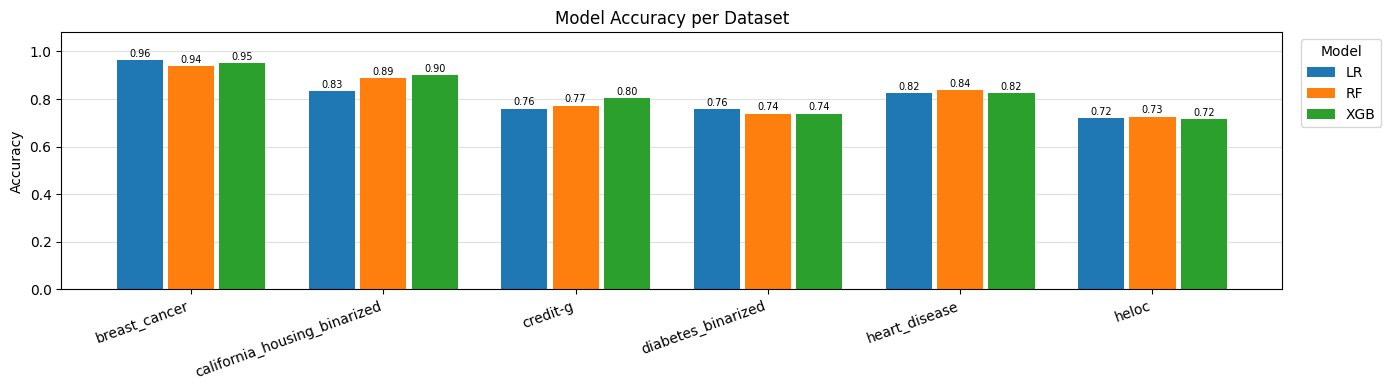


=== Model ROC-AUC by dataset (mean over seeds) ===



model,LR,RF,XGB
dataset,,,
breast_cancer,0.996,0.984,0.988
california_housing_binarized,0.916,0.959,0.966
credit-g,0.817,0.822,0.822
diabetes_binarized,0.876,0.818,0.813
heart_disease,0.923,0.901,0.903
heloc,0.788,0.796,0.792


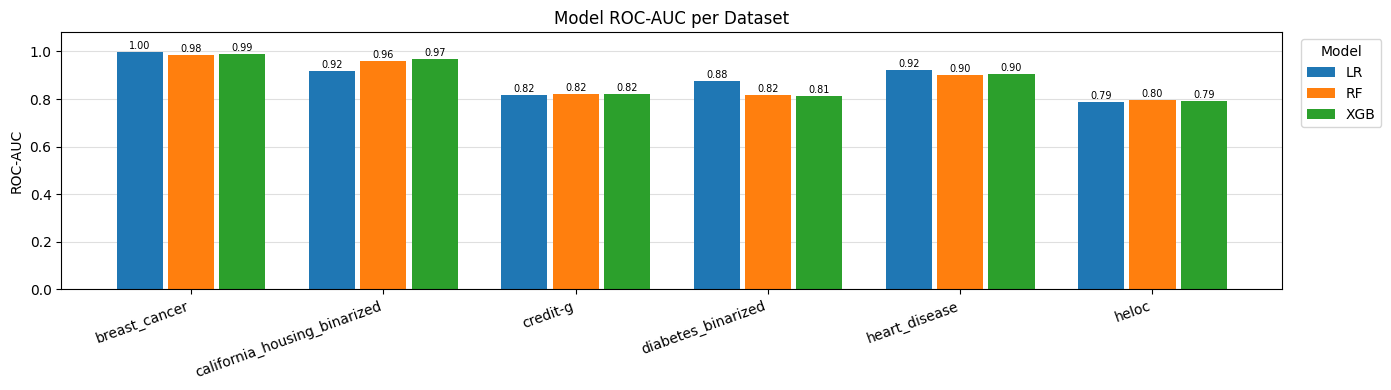

In [29]:
table = plot_accuracy_audit(df_all)            # accuracy (default)
table = plot_accuracy_audit(df_all, metric="clf_auc")  # ROC-AUC instead

In [33]:
print("Statuses:", Counter(statuses))

vals, cnts = np.unique(np.array(best_sources, dtype=object), return_counts=True)
order = np.argsort(-cnts)
for v, c in zip(vals[order], cnts[order]):
    print(f"{v:12s}: {c:4d}  ({c/len(best_sources):.1%})")

Statuses: Counter({'ok': 15})
anchor_mix  :   10  (66.7%)
boundary_mix:    4  (26.7%)
guided_noise:    1  (6.7%)


In [22]:
counts = (
    df_all
    .groupby(["dataset", "model", "method", "status"])
    .size()
    .unstack(fill_value=0)
)

pct = counts.div(counts.sum(axis=1), axis=0) * 100
pct

status                                     no_flip     ok
dataset                      model method                
breast_cancer                LR    dice        0.0  100.0
                                   guided     20.0   80.0
                                   nice        0.0  100.0
                             RF    dice        0.0  100.0
                                   guided     20.0   80.0
                                   nice        0.0  100.0
                             XGB   dice        0.0  100.0
                                   guided     40.0   60.0
                                   nice        0.0  100.0
california_housing_binarized LR    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             RF    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             XGB   dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
credit-g                     LR    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             RF    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             XGB   dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
diabetes_binarized           LR    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             RF    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             XGB   dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
heart_disease                LR    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             RF    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             XGB   dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
heloc                        LR    dice        0.0  100.0
                                   guided      0.0  100.0
                                   nice        0.0  100.0
                             RF    dice        0.0  100.0
                                   guided     20.0   80.0
                                   nice        0.0  100.0
                             XGB   dice        0.0  100.0
                                   guided     20.0   80.0
                                   nice        0.0  100.0

In [24]:
success = (df_all
           .groupby(["dataset","model","method"])["flip_ok"]
           .mean()
           .reset_index())

perf = (df_all
        .groupby(["dataset","model","method"])[["l0","l2","margin_cf","time_s"]]
        .median()
        .reset_index())
print(success)
print("=============================================================================")
print(perf)

                         dataset model  method  flip_ok
0                  breast_cancer    LR    dice      1.0
1                  breast_cancer    LR  guided      0.8
2                  breast_cancer    LR    nice      1.0
3                  breast_cancer    RF    dice      1.0
4                  breast_cancer    RF  guided      0.8
5                  breast_cancer    RF    nice      1.0
6                  breast_cancer   XGB    dice      1.0
7                  breast_cancer   XGB  guided      0.6
8                  breast_cancer   XGB    nice      1.0
9   california_housing_binarized    LR    dice      1.0
10  california_housing_binarized    LR  guided      1.0
11  california_housing_binarized    LR    nice      1.0
12  california_housing_binarized    RF    dice      1.0
13  california_housing_binarized    RF  guided      1.0
14  california_housing_binarized    RF    nice      1.0
15  california_housing_binarized   XGB    dice      1.0
16  california_housing_binarized   XGB  guided  

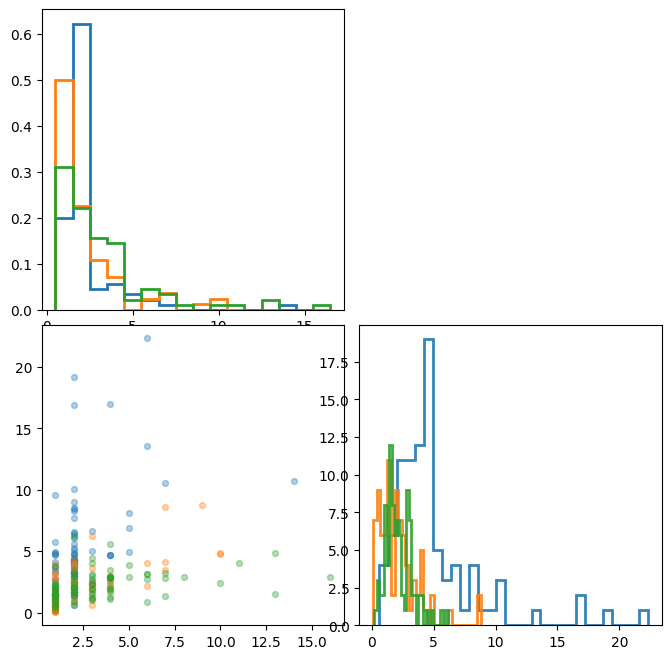

In [30]:
def plot_cornerl(df):
    df = df[df["model"] != "TabPFN"].copy()
    #fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    rate = (
        df.groupby(["model", "method"], as_index=False)["flip_ok"]
        .mean()
    )

    models = rate["model"].unique()
    methods = rate["method"].unique()
    fig, ax = plt.subplots(
        2, 2,
        figsize=(8, 8),
        gridspec_kw={"wspace": 0.05, "hspace": 0.05}
    )

    ax00, ax01 = ax[0, 0], ax[0, 1]
    ax10, ax11 = ax[1, 0], ax[1, 1]

    ax01.axis("off")  # empty corner

    dfp = df[df["method"].isin(methods)].dropna(subset=["l0", "l2"])
    cmap = plt.get_cmap("tab10")
    method_color = {m: cmap(i) for i, m in enumerate(methods)}
    # -------------------------
    # Discrete ℓ0 bins (integer aligned)
    # -------------------------
    l0_min = int(np.floor(dfp["l0"].min()))
    l0_max = int(np.ceil(dfp["l0"].max()))
    bins_l0 = np.arange(l0_min - 0.5, l0_max + 1.5, 1)

    # Continuous ℓ2 bins
    bins_l2 = 30

    for method in methods:
        sub = dfp[dfp["method"] == method]
        if sub.empty:
            continue

        color = method_color.get(method, None)

        # ---- scatter (bottom-right) ----
        ax10.scatter(
            sub["l0"],
            sub["l2"],
            color=color,
            alpha=0.35,
            s=18,
            label=method
        )

        # ---- ℓ0 histogram (top-right, discrete) ----
        ax00.hist(
            sub["l0"],
            bins=bins_l0,
            density=True,
            histtype="step",
            linewidth=2,
            color=color
        )

        # ---- ℓ2 histogram (bottom-left, horizontal) ----
        ax11.hist(
            sub["l2"],
            bins=bins_l2,
            #density=True,
            #orientation="horizontal",
            histtype="step",
            linewidth=2,
            alpha=0.9,
            color=color
        )

    # -------------------------
    # Axis alignment
    # -------------------------
    # ax11.set_xlim(l0_min - 0.5, l0_max + 0.5)
    # ax01.set_xlim(ax11.get_xlim())
    # ax10.set_ylim(ax11.get_ylim())

    # # -------------------------
    # # Labels & cosmetics
    # # -------------------------
    # ax01.tick_params(labelbottom=False)
    # ax10.tick_params(labelleft=False)

    # ax11.set_xlabel(r"$\ell_0$")
    # ax11.set_ylabel(r"$\ell_2$")

    # ax01.set_title(r"$\ell_0$ (discrete)")
    # ax10.set_title(r"$\ell_2$")

    # ax11.grid(True, alpha=0.25)
    # ax11.legend(title="Method", frameon=False)

    plt.show()
plot_cornerl(df_all)

/var/folders/v3/8m8d5hfj2zdby10rq6l2ttyw0000gn/T/ipykernel_27406/2795803421.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


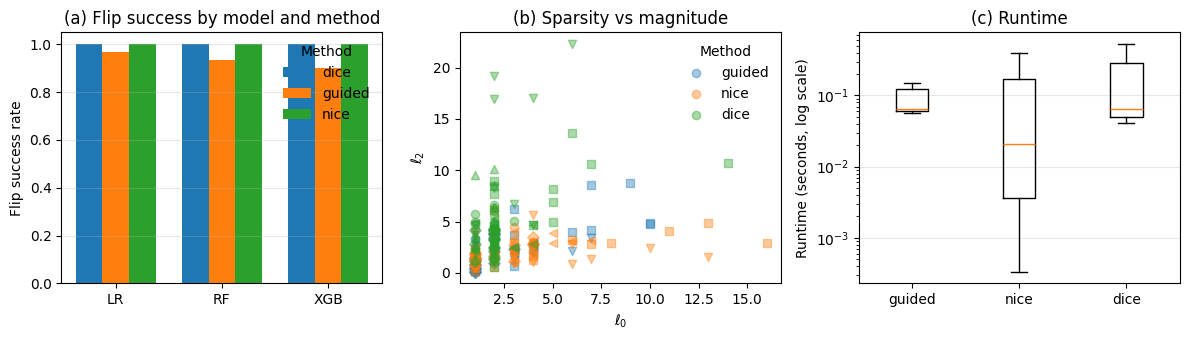

In [27]:
def plot_cf_summary(df):
    df = df[df["model"] != "TabPFN"].copy()
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    # ---------------------------
    # (1) Flip success rate
    # ---------------------------
    # rate = df.groupby("method", as_index=False)["flip_ok"].mean()

    # axes[0].bar(rate["method"], rate["flip_ok"])
    # axes[0].set_ylim(0, 1.05)
    # axes[0].set_ylabel("Flip success rate")
    # axes[0].set_title("(a) Flip success")
    # axes[0].grid(axis="y", alpha=0.3)

    rate = (
        df.groupby(["model", "method"], as_index=False)["flip_ok"]
        .mean()
    )

    models = rate["model"].unique()
    methods = rate["method"].unique()

    x = np.arange(len(models))
    width = 0.25

    for i, method in enumerate(methods):
        vals = [
            rate[(rate["model"] == m) & (rate["method"] == method)]["flip_ok"].values[0]
            if not rate[(rate["model"] == m) & (rate["method"] == method)].empty
            else 0.0
            for m in models
        ]
        axes[0].bar(x + (i - (len(methods)-1)/2) * width, vals, width, label=method)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models)
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Flip success rate")
    axes[0].set_title("(a) Flip success by model and method")
    axes[0].legend(title="Method", frameon=False)
    axes[0].grid(axis="y", alpha=0.3)

    # ---------------------------
    # (2) l0 vs l2 scatter
    # ---------------------------
    methods = df["method"].unique()
    datasets = df["dataset"].unique()

    cmap = plt.get_cmap("tab10")
    method_color = {m: cmap(i) for i, m in enumerate(methods)}

    markers = ["o", "s", "D", "^", "v", "<", ">", "P", "X", "*"]
    marker_map = {ds: markers[i % len(markers)] for i, ds in enumerate(datasets)}

    for method in methods:
        sub_m = df[df["method"] == method]
        for ds in datasets:
            sub = sub_m[sub_m["dataset"] == ds]
            if sub.empty:
                continue
            if method=='guided':
                x = sub["l0"]
            elif method=='dice':
                x = sub["l0"]
            elif method=='nice':
                x = sub["l0"]
            else:
                print("error")
            axes[1].scatter(
                sub["l0"],
                sub["l2"],
                color=method_color[method],
                marker=marker_map[ds],
                alpha=0.4,
                label=method if ds == datasets[0] else None
            )

    axes[1].set_xlabel(r"$\ell_0$")
    axes[1].set_ylabel(r"$\ell_2$")
    axes[1].set_title("(b) Sparsity vs magnitude")
    #axes[1].set_xlim([0,15])
    #axes[1].grid(True, alpha=0.3)
    axes[1].legend(title="Method", frameon=False)

    # ---------------------------
    # (3) Runtime distribution
    # ---------------------------
    data = [df[df["method"] == m]["time_s"].values for m in methods]

    axes[2].boxplot(
        data,
        labels=methods,
        showfliers=False,
    )
    axes[2].set_yscale("log")  # runtime spans orders of magnitude
    axes[2].set_ylabel("Runtime (seconds, log scale)")
    axes[2].set_title("(c) Runtime")
    axes[2].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    #plt.show()
plot_cf_summary(df_all)

In [28]:
i = 220
ds_ind = 1
ds_in = real_datasets[ds_ind].name
model_in = 'dice'
cf_method = 'guided'
sel = (df_all.idx==i)&(df_all.dataset==ds_in)&(df_all.model==model_in)&(df_all.method==cf_method)
df_comp = pd.concat([
    pd.Series(inverse_preprocess(df_all[sel]['x_f'].iloc[0],pre_dict[ds_in],real_datasets[ds_ind].num_cols,real_datasets[ds_ind].cat_cols)),
    pd.Series(inverse_preprocess(df_all[sel]['x_cf'].iloc[0],pre_dict[ds_in],real_datasets[ds_ind].num_cols,real_datasets[ds_ind].cat_cols))
], axis=1).rename(columns={0:'x_f',1:'x_cf'})
#df_comp['change'] = abs(df_comp['x_cf'] - df_comp['x_f'])>1e-6
df_comp

IndexError: single positional indexer is out-of-bounds

In [ ]:
def plot_l0_vs_l2(df):
    methods = ['dice', 'nice', 'guided'] #df["method"].unique()
    datasets = df["dataset"].unique()

    # Explicit color map for methods
    cmap = plt.get_cmap("tab10")
    method_color = {m: cmap(i) for i, m in enumerate(methods)}

    # Marker map for datasets (no legend)
    markers = ["o", "s", "D", "^", "v", "<", ">", "P", "X", "*"]
    marker_map = {ds: markers[i % len(markers)] for i, ds in enumerate(datasets)}

    fig, ax = plt.subplots(figsize=(6, 4))

    for method in methods:
        sub_m = df[df["method"] == method]
        for ds in datasets:
            sub = sub_m[sub_m["dataset"] == ds]
            if sub.empty:
                continue

            ax.scatter(
                sub["l0"],
                sub["l2"],
                color=method_color[method],     # ← FIXED
                marker=marker_map[ds],
                alpha=0.85,
                label=method if ds == datasets[0] else None,
            )

    ax.set_xlabel(r"$\ell_0$ (number of changed features)")
    ax.set_ylabel(r"$\ell_2$ distance")
    ax.set_xlim([0,15])
    ax.set_title("Sparsity vs Magnitude of Counterfactuals")

    ax.legend(title="Method", frameon=False)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

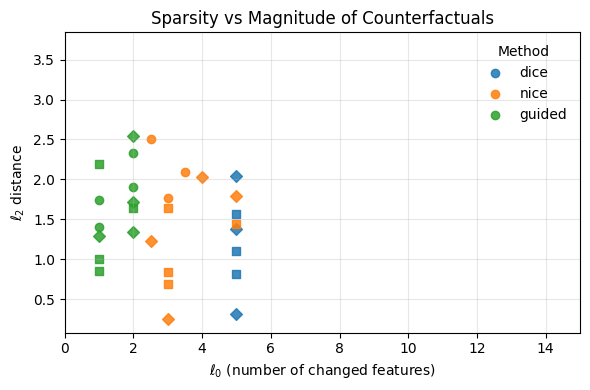

In [ ]:
plot_l0_vs_l2(perf)

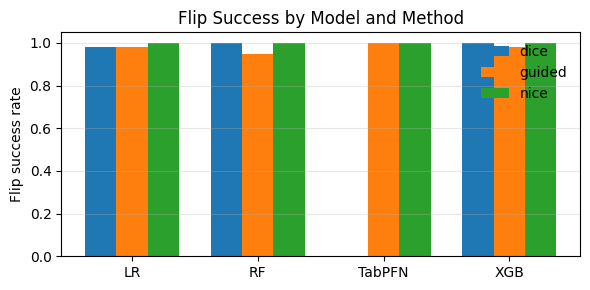

In [ ]:
rate = (
    success
    .groupby(["model", "method"], as_index=False)["flip_ok"]
    .mean()
)

models = rate["model"].unique()
methods = rate["method"].unique()

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(6, 3))

for i, method in enumerate(methods):
    vals = [
        rate[(rate["model"] == m) & (rate["method"] == method)]["flip_ok"].values[0]
        if not rate[(rate["model"] == m) & (rate["method"] == method)].empty
        else 0.0
        for m in models
    ]
    ax.bar(x + (i - 1) * width, vals, width, label=method)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Flip success rate")
ax.set_ylim(0, 1.05)
ax.set_title("Flip Success by Model and Method")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

KeyError: 'mc_f20_red5_inf6_seed1843824992'

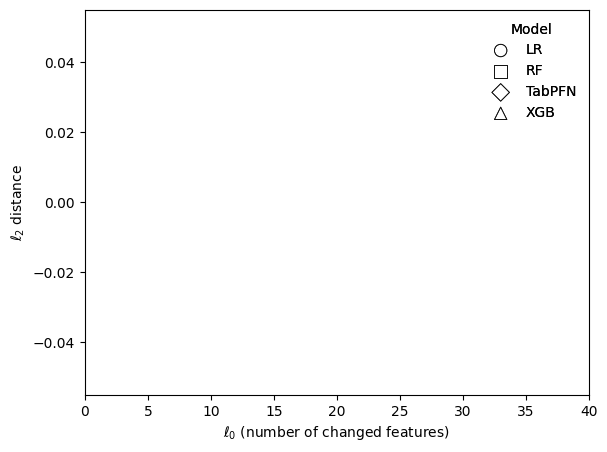

In [ ]:
# assuming your dataframe is called perf
df = perf.copy()

# --- encodings ---
datasets = df["dataset"].unique()
models = df["model"].unique()

color_map = {
    "breast_cancer": "tab:blue",
    "credit-g": "tab:orange",
    "diabetes_binarized": "tab:green",
}

marker_map = {
    "LR": "o",
    "RF": "s",
    "XGB": "^",
    "TabPFN": "D",
}

fig, ax = plt.subplots(figsize=(6.5, 5))

for model in models:
    sub = df[df["model"] == model]
    try:
        ax.scatter(
            sub["l0"],
            sub["l2"],
            c=sub["dataset"].map(color_map),
            marker=marker_map.get(model, "o"),
            s=80,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.6,
            label=model,
        )
    except Exception:
        continue

# axis labels
ax.set_xlabel(r"$\ell_0$ (number of changed features)")
ax.set_ylabel(r"$\ell_2$ distance")
ax.set_xlim([0,40])

# legends
model_legend = ax.legend(title="Model", loc="upper right",frameon=False)
ax.add_artist(model_legend)

dataset_handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               label=ds, markerfacecolor=color_map[ds], markersize=8)
    for ds in datasets
]
ax.legend(handles=dataset_handles, title="Dataset", loc="lower right",frameon=False)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

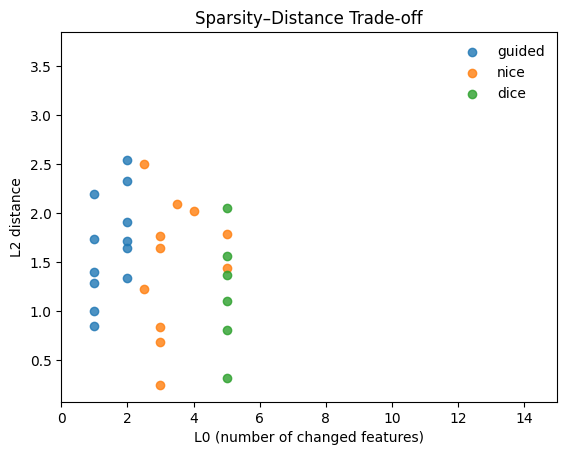

In [ ]:
plt.figure()
for method in ["guided", "nice","dice"]:
    sub = perf[(perf["method"] == method)]
    plt.scatter(
        sub["l0"], sub["l2"],
        label=method,
        alpha=0.8
    )

plt.xlabel("L0 (number of changed features)")
plt.ylabel("L2 distance")
plt.legend(frameon=False)
plt.title("Sparsity–Distance Trade-off")
plt.xlim([0,15])
plt.show()

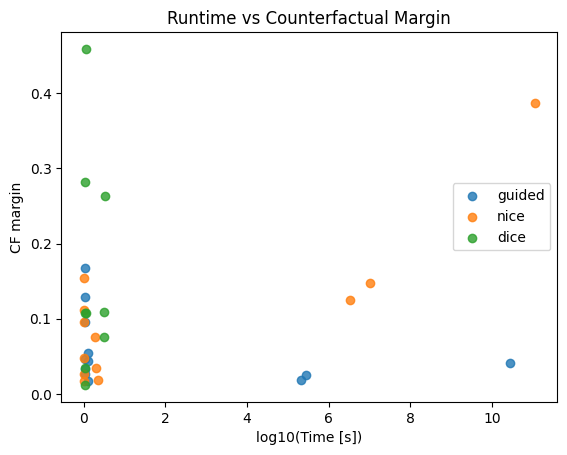

In [ ]:
plt.figure()
for method in ["guided", "nice","dice"]:
    sub = perf[(perf["method"] == method)] #& (~df["failed"])]
    plt.scatter(
        sub["time_s"], sub["margin_cf"],
        label=method,
        alpha=0.8
    )

plt.xlabel("log10(Time [s])")
plt.ylabel("CF margin")
plt.legend()
plt.title("Runtime vs Counterfactual Margin")
plt.show()


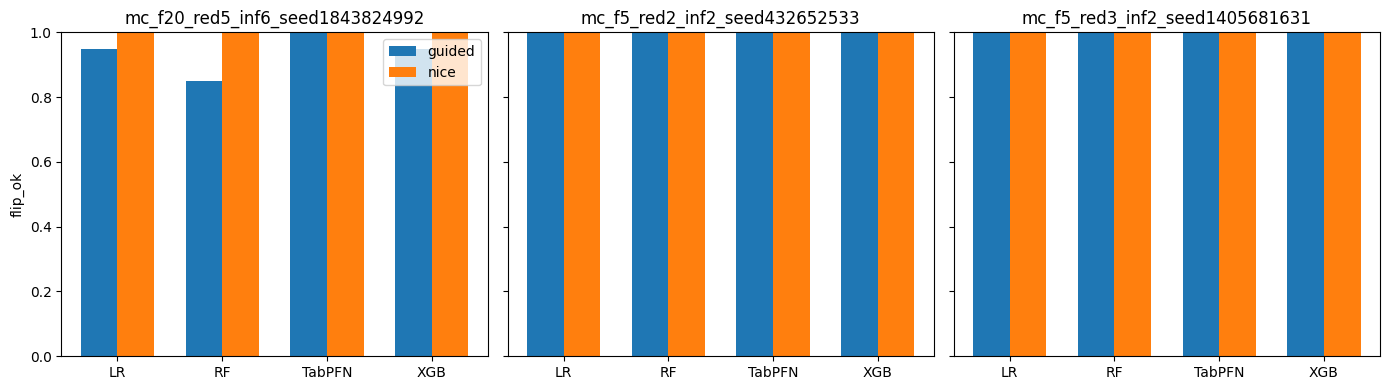

In [ ]:
datasets = success["dataset"].unique()
models = success["model"].unique()
methods = ["guided", "nice"]

fig, axes = plt.subplots(1, len(datasets), figsize=(14, 4), sharey=True)

if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = success[success["dataset"] == ds]

    x = np.arange(len(models))
    width = 0.35

    for i, method in enumerate(methods):
        vals = [
            sub[(sub["model"] == m) & (sub["method"] == method)]["flip_ok"].values[0]
            for m in models
        ]
        ax.bar(x + (i - 0.5) * width, vals, width, label=method)

    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("flip_ok")
axes[0].legend()

plt.tight_layout()
plt.show()

In [ ]:
statuses = (
    df_all["status"]
    .fillna("unknown")
    .unique()
)
statuses = sorted(statuses)
agg = (
    df_all
    .groupby(["dataset", "model", "method", "status"])
    .size()
    .reset_index(name="count")
)

agg["freq"] = agg.groupby(
    ["dataset", "model", "method"]
)["count"].transform(lambda x: x / x.sum())

datasets = agg["dataset"].unique()
models = agg["model"].unique()
methods = ["guided", "nice","dice"]
statuses = sorted(agg["status"].unique())

# --- 1) Explicit, stable status->color map ---
cmap = plt.get_cmap("tab20")  # or "tab10" if <=10 statuses
status_color = {s: cmap(i % cmap.N) for i, s in enumerate(statuses)}

# --- 2) Method->hatch map ---
method_hatch = {"guided": "//", "nice": "||", "dice": "\\\\"}

fig, axes = plt.subplots(1, len(datasets), figsize=(18, 4), sharey=True)
if len(datasets) == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = agg[agg["dataset"] == ds]
    x = np.arange(len(models))
    width = 0.35

    for i, method in enumerate(methods):
        bottom = np.zeros(len(models))

        for status in statuses:
            vals = []
            for m in models:
                v = sub[(sub.model == m) & (sub.method == method) & (sub.status == status)]["freq"]
                vals.append(v.iloc[0] if len(v) else 0.0)

            ax.bar(
                x + (i - 0.5) * width,
                vals,
                width,
                bottom=bottom,
                color=status_color[status],          # <- pinned color
                hatch=method_hatch.get(method, None),
                edgecolor="black",                  # hatch uses edgecolor
                linewidth=0.5
            )
            bottom += np.array(vals)

    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Fraction of outcomes")

# --- 3) Build legends from custom patches (guaranteed exact colors) ---
status_handles = [Patch(facecolor=status_color[s], edgecolor="black", label=s) for s in statuses]
method_handles = [
    Patch(facecolor="white", edgecolor="black", hatch=method_hatch[m], label=m)
    for m in methods
]

fig.legend(status_handles, statuses, title="Status", loc="upper center", ncol=min(len(statuses), 6))
fig.legend(method_handles, methods, title="Method", loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

NameError: name 'df_all' is not defined

In [ ]:
def _pick_row(df_all, *, idx, dataset, model, method):
    sel = (
        (df_all["idx"] == idx) &
        (df_all["dataset"] == dataset) &
        (df_all["model"] == model) &
        (df_all["method"] == method)
    )
    n = int(sel.sum())
    if n != 1:
        raise ValueError(f"Selection must match exactly 1 row; got {n}.")
    return df_all.loc[sel].iloc[0]

def _comp_original(x_f, x_cf, *, pre, num_cols, cat_cols, tol_num=1e-6):
    s_f = pd.Series(inverse_preprocess(x_f, pre, num_cols, cat_cols), name="x_f")
    s_c = pd.Series(inverse_preprocess(x_cf, pre, num_cols, cat_cols), name="x_cf")
    dfc = pd.concat([s_f, s_c], axis=1)

    dfc["diff"] = np.nan
    dfc["changed"] = False

    for col in dfc.index:
        a, b = dfc.loc[col, "x_f"], dfc.loc[col, "x_cf"]
        if col in num_cols:
            aa = pd.to_numeric(a, errors="coerce")
            bb = pd.to_numeric(b, errors="coerce")
            if pd.notna(aa) and pd.notna(bb):
                dfc.loc[col, "diff"] = float(bb - aa)
                dfc.loc[col, "changed"] = (abs(bb - aa) > tol_num)
            else:
                dfc.loc[col, "changed"] = (str(a) != str(b))
        else:
            dfc.loc[col, "changed"] = (str(a) != str(b))

    # sort: changed first, then numeric by |diff|
    dfc["_absdiff"] = dfc["diff"].abs()
    dfc = dfc.sort_values(["changed", "_absdiff"], ascending=[False, False]).drop(columns="_absdiff")
    return dfc

def view_cf_original_space(
    df_all,
    *,
    idx,
    dataset,
    model,
    method,
    pre,
    num_cols,
    cat_cols,
    # plausibility input (original space training df)
    X_train_df=None,          # optional: pd.DataFrame in ORIGINAL space with columns = num_cols+cat_cols
    z_thresh=4.0,             # mark very extreme numeric moves
    q_low=0.005,
    q_high=0.995,
    top_k=30,
    tol_num=1e-6,
    print_table=True,
):
    r = _pick_row(df_all, idx=idx, dataset=dataset, model=model, method=method)

    dfc = _comp_original(
        r["x_f"], r["x_cf"],
        pre=pre, num_cols=num_cols, cat_cols=cat_cols,
        tol_num=tol_num
    )

    changed = dfc[dfc["changed"]].copy()

    # --- plausibility flags (numeric only) ---
    changed["plaus_flag"] = ""
    if X_train_df is not None:
        # Use robust quantile + z-score style checks
        stats = {}
        for c in num_cols:
            s = pd.to_numeric(X_train_df[c], errors="coerce").dropna()
            if len(s) < 10:
                continue
            mu = float(s.mean())
            sd = float(s.std(ddof=0)) if float(s.std(ddof=0)) > 0 else np.nan
            lo = float(s.quantile(q_low))
            hi = float(s.quantile(q_high))
            stats[c] = (mu, sd, lo, hi)

        def flag_num(col, val):
            if col not in stats:
                return ""
            mu, sd, lo, hi = stats[col]
            try:
                v = float(val)
            except Exception:
                return ""
            flags = []
            if np.isfinite(sd) and sd > 0:
                z = abs((v - mu) / sd)
                if z >= z_thresh:
                    flags.append(f"|z|≥{z_thresh:g}")
            if v < lo or v > hi:
                flags.append(f"outside[{q_low:g},{q_high:g}]")
            return ",".join(flags)

        for c in changed.index:
            if c in num_cols:
                f1 = flag_num(c, changed.loc[c, "x_f"])
                f2 = flag_num(c, changed.loc[c, "x_cf"])
                if f1 or f2:
                    changed.loc[c, "plaus_flag"] = f"f:{f1} cf:{f2}".strip()

    # --- plot (numeric dumbbell + categorical text) ---
    if changed.empty:
        print("No changes detected in original space.")
        return dfc, r

    # split numeric vs categorical
    num_changed = changed.loc[changed.index.intersection(num_cols)].copy()
    cat_changed = changed.loc[changed.index.intersection(cat_cols)].copy()

    # keep top_k numeric by |diff|, but include all categoricals
    num_changed = num_changed.sort_values("diff", key=lambda s: s.abs(), ascending=False)
    if top_k is not None:
        num_changed = num_changed.head(max(0, top_k - len(cat_changed)))

    plot_df = pd.concat([cat_changed, num_changed], axis=0)

    # reverse for nicer y ordering
    plot_df = plot_df.iloc[::-1]
    y = np.arange(len(plot_df))

    plt.figure(figsize=(11, max(3.5, 0.35 * len(plot_df))))

    # numeric rows: dumbbell
    for yi, (feat, row) in enumerate(plot_df.iterrows()):
        if feat in num_cols:
            a = pd.to_numeric(row["x_f"], errors="coerce")
            b = pd.to_numeric(row["x_cf"], errors="coerce")
            if pd.notna(a) and pd.notna(b):
                plt.plot([a, b], [yi, yi], marker="o")
                if row.get("plaus_flag"):
                    plt.text(max(a, b), yi, f"  {row['plaus_flag']}", va="center", fontsize=9)
            else:
                plt.text(0.02, yi, f"{row['x_f']} → {row['x_cf']}", transform=plt.gca().get_yaxis_transform(), va="center")
        else:
            # categorical: show "from -> to" on left margin
            plt.text(0.02, yi, f"{row['x_f']} → {row['x_cf']}",
                     transform=plt.gca().get_yaxis_transform(), va="center")

    plt.yticks(y, plot_df.index)
    plt.xlabel("Value (original space)  /  categorical changes annotated")
    title = (
        f"{dataset} | {model} | {method} | idx={idx} | "
        f"flip_ok={r.get('flip_ok')} p_f={r.get('p_f'):.3f} p_cf={r.get('p_cf'):.3f} "
        f"margin={r.get('margin_cf'):.3f} l0={r.get('l0')} l2={r.get('l2')}"
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

    if print_table:
        # show a compact table of changes
        out = plot_df[["x_f", "x_cf", "diff", "plaus_flag"]].copy()
        display(out)

    return dfc, r

In [ ]:
i = 220
ds_ind = 1
ds = real_datasets[ds_ind].name
model = "TabPFN"

X_train_df_orig = real_datasets[ds_ind].X_df  # or whatever your original-space training df is

for method in ["guided", "nice"]:
    _dfc, row = view_cf_original_space(
        df_all,
        idx=i, dataset=ds, model=model, method=method,
        pre=pre_dict[ds],
        num_cols=real_datasets[ds_ind].num_cols,
        cat_cols=real_datasets[ds_ind].cat_cols,
        X_train_df=X_train_df_orig,   # enables plausibility flags
        top_k=30
    )

NameError: name 'df_all' is not defined

In [ ]:
# statuses = (
#     df_all["status"]
#     .fillna("unknown")
#     .unique()
# )
# statuses = sorted(statuses)
# agg = (
#     df_all
#     .groupby(["dataset", "model", "method", "status"])
#     .size()
#     .reset_index(name="count")
# )

# agg["freq"] = agg.groupby(
#     ["dataset", "model", "method"]
# )["count"].transform(lambda x: x / x.sum())

# datasets = agg["dataset"].unique()
# models = agg["model"].unique()
# methods = ["guided", "nice"]

# method_hatch = {
#     "guided": "//",      # diagonal
#     "nice": "\\\\",      # opposite diagonal
#     # if you rename later:
#     # "proposal": "//",
# }

# datasets = agg["dataset"].unique()
# models = agg["model"].unique()
# methods = ["guided", "nice"]
# statuses = sorted(agg["status"].unique())

# fig, axes = plt.subplots(1, len(datasets), figsize=(15, 4), sharey=True)

# if len(datasets) == 1:
#     axes = [axes]

# for ax, ds in zip(axes, datasets):
#     sub = agg[agg["dataset"] == ds]

#     x = np.arange(len(models))
#     width = 0.35

#     for i, method in enumerate(methods):
#         bottom = np.zeros(len(models))

#         for status in statuses:
#             vals = []
#             for m in models:
#                 v = sub[
#                     (sub.model == m) &
#                     (sub.method == method) &
#                     (sub.status == status)
#                 ]["freq"]
#                 vals.append(v.iloc[0] if len(v) else 0.0)

#             bars = ax.bar(
#                 x + (i - 0.5) * width,
#                 vals,
#                 width,
#                 bottom=bottom,
#                 label=status if (i == 0) else None,  # status legend once
#                 hatch=method_hatch.get(method, None),
#                 edgecolor="black",
#                 linewidth=0.5,
#             )

#             bottom += np.array(vals)

#     ax.set_title(ds)
#     ax.set_xticks(x)
#     ax.set_xticklabels(models)
#     ax.set_ylim(0, 1)

# axes[0].set_ylabel("Fraction of outcomes")
# # --- Status legend (colors) ---
# status_handles, status_labels = axes[0].get_legend_handles_labels()
# fig.legend(
#     status_handles,
#     status_labels,
#     title="Status",
#     loc="upper center",
#     ncol=len(statuses),
# )

# # --- Method legend (hatches) ---
# method_handles = [
#     plt.Rectangle((0, 0), 1, 1, facecolor="white",
#                   edgecolor="black", hatch=method_hatch[m])
#     for m in methods
# ]
# fig.legend(
#     method_handles,
#     methods,
#     title="Method",
#     loc="upper right",
# )

# plt.tight_layout(rect=[0, 0, 1, 0.85])
# plt.show()